In [1]:
from astropy.io import fits
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler, StandardScaler

In [2]:
hdulist = fits.open('../../data/allStarLite-dr17-synspec_rev1.fits')
hdu1_data = hdulist[1].data
df4 = pd.DataFrame(hdu1_data.tolist(), columns=hdu1_data.names)



In [3]:
df = df4

In [4]:
df = df.drop_duplicates(subset='APOGEE_ID')

In [5]:
df.head()

,APOGEE_ID,TELESCOPE,FIELD,ALT_ID,RA,DEC,GLON,GLAT,J,J_ERR,...,NI_FE_ERR,NI_FE_FLAG,CU_FE,CU_FE_SPEC,CU_FE_ERR,CU_FE_FLAG,CE_FE,CE_FE_SPEC,CE_FE_ERR,CE_FE_FLAG
0,VESTA,apo1m,calibration,,NaN,NaN,292.219131,-30.602919,99.999001,0.000,...,0.010266,0,NaN,NaN,0.059403,2,NaN,NaN,NaN,64
1,2M00000002+7417074,apo25m,120+12,none,0.000103,74.285408,119.401807,11.767414,8.597000,0.039,...,0.010609,0,NaN,NaN,0.001221,2,NaN,NaN,NaN,64
2,2M00000019-1924498,apo25m,060-75,none,0.000832,-19.413851,63.394122,-75.906397,11.074000,0.022,...,0.013835,0,NaN,NaN,0.102594,2,NaN,NaN,NaN,64
3,2M00000032+5737103,apo25m,116-04,none,0.001335,57.619530,116.065371,-4.564768,10.905000,0.023,...,0.016555,0,NaN,NaN,0.123839,2,NaN,NaN,NaN,64
5,2M00000035-7323394,lco25m,SMC12,none,0.001467,-73.394287,307.939441,-43.230305,15.008000,0.045,...,0.053997,0,NaN,NaN,0.276795,2,-0.15516,-0.0995,0.146837,0


In [6]:
df_classes = pd.read_csv('../../data/classes.csv')

In [9]:
df_merged = pd.merge(df_classes, df, left_on='apogee_id', right_on='APOGEE_ID', how='inner')

In [17]:
variable_selection = ['apogee_id', "J", "H", "K","LOGG", "M_H", "VMICRO", "VMACRO", "VSINI", 'C_FE', 'CI_FE', 'N_FE', 'O_FE', 'NA_FE', 'MG_FE', 'AL_FE', 'SI_FE', 'S_FE', 'K_FE', 'CA_FE', 
    'TI_FE', 'TIII_FE', 'V_FE', 'CR_FE', 'MN_FE', 'CO_FE', 'NI_FE', 'CE_FE', 'FE_H', 
    'class_spectral', 'class_lum_logg', 'class_lum_jhk', 'class_lum_bins_logg', 'class_lum_bins_jhk', 'STARFLAGS',"ASPCAPFLAGS"]

In [18]:
sample = df_merged[variable_selection]

In [19]:
sample = sample.drop(columns=["VSINI", "TIII_FE", "CO_FE", "CE_FE"])

In [20]:
#créer un dataset qui contient les lignes sans valeurs manquantes
sample_0_miss = sample.dropna()

In [26]:
# print unique starflags value counts, starflags is a column that contains the flags ( alist )of the star, so parse the list and count the unique values

from collections import Counter

counter = Counter()
for flags in df['STARFLAGS']:
    flag_list = flags.split(',')
    counter.update(flag_list)

print("\nUnique starflag counts using Counter:")
print(counter)

counter_aspcap = Counter()
for flags in df['ASPCAPFLAGS']:
    flag_list = flags.split(',')
    counter_aspcap.update(flag_list)

print("\nUnique ASPCAPFLAG counts using Counter:")
print(counter_aspcap)



Unique starflag counts using Counter:
Counter({'': 356768, 'MTPFLUX_LT_75': 88900, 'BRIGHT_NEIGHBOR': 86182, 'PERSIST_LOW': 72453, 'PERSIST_HIGH': 48382, 'SUSPECT_BROAD_LINES': 29472, 'MTPFLUX_LT_50': 28867, 'SUSPECT_ROTATION': 27849, 'PERSIST_MED': 23039, 'LOW_SNR': 19449, 'MULTIPLE_SUSPECT': 9476, 'RV_FAIL': 3611, 'PERSIST_JUMP_NEG': 3372, 'RV_REJECT': 3185, 'PERSIST_JUMP_POS': 1559, 'VERY_BRIGHT_NEIGHBOR': 548, 'BAD_PIXELS': 33})

Unique ASPCAPFLAG counts using Counter:
Counter({'': 321929, 'VMICRO_WARN': 189613, 'VSINI_WARN': 151133, 'N_M_WARN': 142131, 'STAR_WARN': 90773, 'COLORTE_WARN': 75411, 'STAR_BAD': 35976, 'SN_BAD': 24449, 'TEFF_WARN': 23907, 'LOGG_WARN': 15489, 'NO_ASPCAP_RESULT': 11256, 'NO_GRID': 11256, 'VSINI_BAD': 10910, 'MISSING_APSTAR': 9546, 'MULTIPLE_SUSPECT': 9472, 'C_M_WARN': 7538, 'TEFF_BAD': 7484, 'LOGG_BAD': 7287, 'M_H_WARN': 5055, 'M_H_BAD': 4691, 'PROBLEM_TARGET': 3829, 'C_M_BAD': 3540, 'CHI2_BAD': 3540, 'VMICRO_BAD': 3380, 'ROTATION_WARN': 3362, 'ALPHA_M_W

In [36]:
# Define the flags that, if present, should cause the row to be dropped
to_delete_flags = ['LOW_SNR', 'STAR_BAD', "CHI2_BAD", "LOGG_BAD", "TEFF_BAD", "BRIGHT_NEIGHBOR", "MTPFLUX_LT_75", "PERSIST_LOW", "PERSIST_HIGH", "PERSIST_MED", "SUSPECT_ROTATION", "VMICRO_WARN",
                   ]

to_delete_aspcap = ['VMICRO_WARN', 'N_M_WARN', 'VSINI_WARN', 'TEFF_WARN', 'STAR_WARN', 'C_M_WARN', 'COLORTE_WARN', 'LOGG_WARN', 'VMICRO_BAD', 'SN_BAD', 'ROTATION_WARN', 'C_M_BAD', 'VSINI_BAD', 'CHI2_WARN', 'ALPHA_M_WARN',
                    'VSINI_WARN', 'TEFF_WARN', 'N_M_WARN', 'STAR_WARN', 'C_M_WARN', 'COLORTE_WARN', 'LOGG_WARN', 'SN_BAD', 'VSINI_BAD', 'CHI2_WARN', 'ROTATION_WARN']

# Create a mask that is True for rows that do NOT contain any of the delete flags
mask = sample_0_miss['STARFLAGS'].apply(
    lambda x: not any(flag in to_delete_flags for flag in x.split(','))
)

# Filter the dataframe
df_filtered = sample_0_miss[mask]


In [37]:
# print unique starflags value counts, starflags is a column that contains the flags ( alist )of the star, so parse the list and count the unique values

from collections import Counter

counter = Counter()
for flags in df_filtered['STARFLAGS']:
    flag_list = flags.split(',')
    counter.update(flag_list)

print("\nUnique starflag counts using Counter:")
print(counter)

# print unique starflags value counts, starflags is a column that contains the flags ( alist )of the star, so parse the list and count the unique values

from collections import Counter

counter_aspcap = Counter()
for flags in df_filtered['ASPCAPFLAGS']:
    flag_list = flags.split(',')
    counter_aspcap.update(flag_list)

print("\nUnique ASPCAPFLAG counts using Counter:")
print(counter_aspcap)

print(counter_aspcap.keys())




Unique starflag counts using Counter:
Counter({'': 277230, 'SUSPECT_BROAD_LINES': 815, 'PERSIST_JUMP_NEG': 14})

Unique ASPCAPFLAG counts using Counter:
Counter({'': 175809, 'VMICRO_WARN': 60943, 'VSINI_WARN': 60328, 'N_M_WARN': 37927, 'STAR_WARN': 17098, 'TEFF_WARN': 9290, 'COLORTE_WARN': 6276, 'LOGG_WARN': 1946, 'SN_BAD': 1132, 'C_M_WARN': 691, 'VSINI_BAD': 323, 'VMICRO_BAD': 125, 'ROTATION_WARN': 75, 'CHI2_WARN': 26, 'C_M_BAD': 18, 'ALPHA_M_WARN': 1})
dict_keys(['VMICRO_WARN', 'N_M_WARN', '', 'VSINI_WARN', 'TEFF_WARN', 'STAR_WARN', 'C_M_WARN', 'COLORTE_WARN', 'LOGG_WARN', 'VMICRO_BAD', 'SN_BAD', 'ROTATION_WARN', 'C_M_BAD', 'VSINI_BAD', 'CHI2_WARN', 'ALPHA_M_WARN'])


In [38]:
mask_aspcap = df_filtered['ASPCAPFLAGS'].apply(
    lambda x: not any(flag in to_delete_aspcap for flag in x.split(','))
)

df_filtered = df_filtered[mask_aspcap]

In [39]:
df_filtered.describe()

,J,H,K,LOGG,M_H,VMICRO,VMACRO,C_FE,CI_FE,N_FE,...,K_FE,CA_FE,TI_FE,V_FE,CR_FE,MN_FE,NI_FE,FE_H,class_lum_bins_logg,class_lum_bins_jhk
count,175809.000000,175809.000000,175809.000000,175809.000000,175809.000000,175809.000000,175809.000000,175809.000000,175809.000000,175809.000000,...,175809.000000,175809.000000,175809.000000,175809.000000,175809.000000,175809.000000,175809.000000,175809.000000,175809.000000,175809.000000
mean,11.153503,10.499123,10.326578,2.480976,-0.212168,1.374391,3.079362,-0.012046,-0.037011,0.206430,...,0.108965,0.044137,0.046261,-0.052099,-0.038197,-0.024341,0.036057,-0.216698,3.242035,3.264725
std,1.276738,1.197937,1.180136,0.744247,0.319376,0.285963,1.273693,0.109290,0.126288,0.143230,...,0.146275,0.078445,0.143768,0.204801,0.153605,0.099810,0.044471,0.317101,1.457100,1.613819
min,7.930000,7.752000,7.711000,0.520265,-2.114400,0.600109,0.000000,-1.297800,-1.449630,-0.571100,...,-2.238787,-0.805914,-0.809432,-2.235949,-2.622367,-1.403897,-0.690208,-2.085100,0.000000,0.000000
25%,10.217000,9.626000,9.472000,2.028082,-0.401340,1.193040,2.805254,-0.067915,-0.112060,0.138468,...,0.024609,-0.007415,-0.002956,-0.159417,-0.066296,-0.070518,0.011663,-0.405680,2.000000,2.000000
50%,11.158000,10.546000,10.383000,2.451514,-0.190560,1.365557,3.263964,-0.005351,-0.035265,0.201540,...,0.093079,0.030091,0.048570,-0.061668,-0.008886,-0.022288,0.037643,-0.194380,3.000000,3.000000
75%,12.082000,11.383000,11.204000,2.770572,0.013335,1.554283,3.729383,0.058279,0.041640,0.261140,...,0.194239,0.081790,0.121285,0.067462,0.033858,0.027861,0.064012,0.009054,4.000000,4.000000
max,14.757000,13.536000,13.244000,4.583931,0.648950,2.399164,10.187533,0.783780,0.959730,1.500300,...,1.262319,0.866525,0.952793,1.624526,1.060944,1.680942,0.397982,0.616290,7.000000,7.000000


In [60]:
#export sample_0_miss en csv
# sample_0_miss.to_csv('../../data/resample_normalized.csv', index=False)
# drop STARFLAGS and ASPCAPFLAGS
from sklearn.preprocessing import StandardScaler

sample_0_miss = df_filtered.drop(columns=['STARFLAGS', 'ASPCAPFLAGS', 'J', 'H', 'K', 'LOGG'])

sample_0_miss.describe()

sample_0_miss.columns

# renormalise 'M_H', 'VMICRO', 'VMACRO', 'C_FE', 'CI_FE', 'N_FE', 'O_FE',
#       'NA_FE', 'MG_FE', 'AL_FE', 'SI_FE', 'S_FE', 'K_FE', 'CA_FE', 'TI_FE',
#       'V_FE', 'CR_FE', 'MN_FE', 'NI_FE', 'FE_H'

scaler = StandardScaler()

sample_0_miss[['M_H', 'VMICRO', 'VMACRO', 'C_FE', 'CI_FE', 'N_FE', 'O_FE', 'NA_FE', 'MG_FE', 'AL_FE', 'SI_FE', 'S_FE', 'K_FE', 'CA_FE', 'TI_FE', 'V_FE', 'CR_FE', 'MN_FE', 'NI_FE', 'FE_H']] = scaler.fit_transform(sample_0_miss[['M_H', 'VMICRO', 'VMACRO', 'C_FE', 'CI_FE', 'N_FE', 'O_FE', 'NA_FE', 'MG_FE', 'AL_FE', 'SI_FE', 'S_FE', 'K_FE', 'CA_FE', 'TI_FE', 'V_FE', 'CR_FE', 'MN_FE', 'NI_FE', 'FE_H']])

sample_0_miss.describe()




,M_H,VMICRO,VMACRO,C_FE,CI_FE,N_FE,O_FE,NA_FE,MG_FE,AL_FE,...,K_FE,CA_FE,TI_FE,V_FE,CR_FE,MN_FE,NI_FE,FE_H,class_lum_bins_logg,class_lum_bins_jhk
count,1.758090e+05,1.758090e+05,1.758090e+05,1.758090e+05,1.758090e+05,1.758090e+05,1.758090e+05,1.758090e+05,1.758090e+05,1.758090e+05,...,1.758090e+05,1.758090e+05,1.758090e+05,1.758090e+05,1.758090e+05,1.758090e+05,1.758090e+05,1.758090e+05,175809.000000,175809.000000
mean,-7.028274e-17,-6.207837e-17,-6.337167e-17,1.907617e-17,-1.131637e-17,8.180119e-17,-6.434165e-17,1.939949e-17,-5.496522e-17,-3.766735e-17,...,-1.163969e-17,3.702070e-17,2.327939e-17,3.006921e-17,5.496522e-18,-1.196302e-17,-8.341781e-17,5.191385e-17,3.242035,3.264725
std,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,...,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,1.457100,1.613819
min,-5.956099e+00,-2.707640e+00,-2.417670e+00,-1.176465e+01,-1.118576e+01,-5.428563e+00,-6.493023e+00,-9.562253e+00,-4.866816e+00,-8.856927e+00,...,-1.605028e+01,-1.083635e+01,-5.951910e+00,-1.066333e+01,-1.682354e+01,-1.382187e+01,-1.633127e+01,-5.892155e+00,0.000000,0.000000
25%,-5.923193e-01,-6.341778e-01,-2.152078e-01,-5.112013e-01,-5.942740e-01,-4.744967e-01,-7.108538e-01,-2.236091e-01,-6.961553e-01,-6.262114e-01,...,-5.766959e-01,-6.571817e-01,-3.423354e-01,-5.240113e-01,-1.829298e-01,-4.626551e-01,-5.485435e-01,-5.959691e-01,2.000000,2.000000
50%,6.765625e-02,-3.088961e-02,1.449352e-01,6.126105e-02,1.382379e-02,-3.414029e-02,-2.579107e-01,1.311168e-01,-2.780961e-01,-1.025749e-01,...,-1.086046e-01,-1.790546e-01,1.605974e-02,-4.672144e-02,1.908222e-01,2.056435e-02,3.566006e-02,7.038247e-02,3.000000,3.000000
75%,7.060740e-01,6.290768e-01,5.103453e-01,6.434740e-01,6.227920e-01,3.819755e-01,6.319065e-01,4.577730e-01,5.166966e-01,5.923651e-01,...,5.829704e-01,4.799930e-01,5.218404e-01,5.837963e-01,4.690956e-01,5.230107e-01,6.286326e-01,7.119270e-01,4.000000,4.000000
max,2.696255e+00,3.583602e+00,5.580772e+00,7.281811e+00,7.892642e+00,9.033550e+00,5.834350e+00,6.440654e+00,5.865096e+00,1.035279e+01,...,7.884842e+00,1.048370e+01,6.305526e+00,8.186647e+00,7.155659e+00,1.708534e+01,8.138504e+00,2.626896e+00,7.000000,7.000000


In [61]:
sample_0_miss.to_csv('../../data/data_reduced_175_standard.csv', index=False)

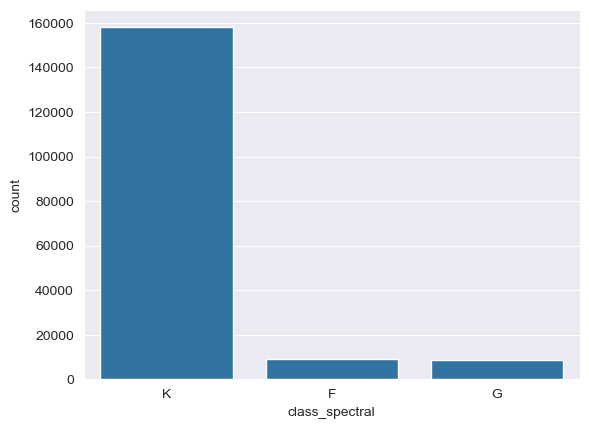

In [62]:
# plot classes distribution

sns.countplot(x='class_spectral', data=df_filtered)
plt.show()


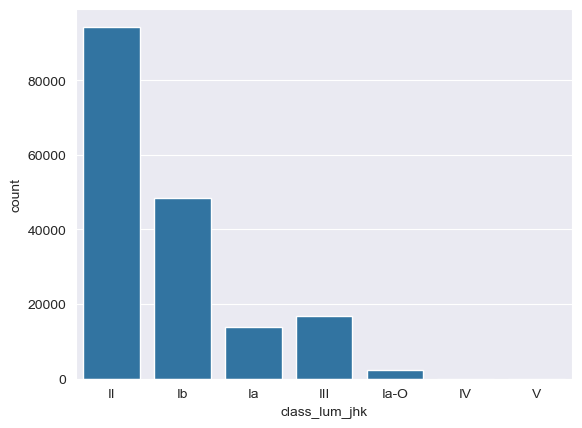

In [63]:
# plot classes distribution

sns.countplot(x='class_lum_jhk', data=df_filtered)
plt.show()
